In [3]:
import csv
import numpy as np
import pandas as pd


#Fixing data 
#put data in a DataFrame
df = pd.read_csv('Assignment_sales_data.csv')

#Fix Data errors with Payment type
df["Payment Type"]= df["Payment Type"].replace('CC', "Credit Card")



#fix negative numbers in quantity
df['Quantity'] = df['Quantity'].abs()

#get rid of pound symbol
df["Total Price"] = df["Total Price"].str.replace('€', '', regex=False)
df["Total Profit"] = df["Total Profit"].str.replace('€', '', regex=False)


#Fixing existing data for profit and price colums --> converting to float value
df['Total Profit'] = df['Total Profit'].astype(float)
df['Total Price'] = df['Total Price'].astype(float)

#fix Date and time
df['Date of Sale'] = df['Date of Sale'].apply(lambda x: pd.to_datetime(x).strftime('%d-%m-%Y'))

#makes it to_datetime for pandas
df['Date of Sale'] = pd.to_datetime(df['Date of Sale'], errors='coerce')

#split product category into different data columns to better graph it
df[['Product Type', 'Category']] = df['Product Category'].str.split('→', n=1, expand=True)

#creates final sorted df csv file
df.to_csv('Final_data_sorted.csv')

In [4]:
#data visualization
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [5]:
#df.describe()

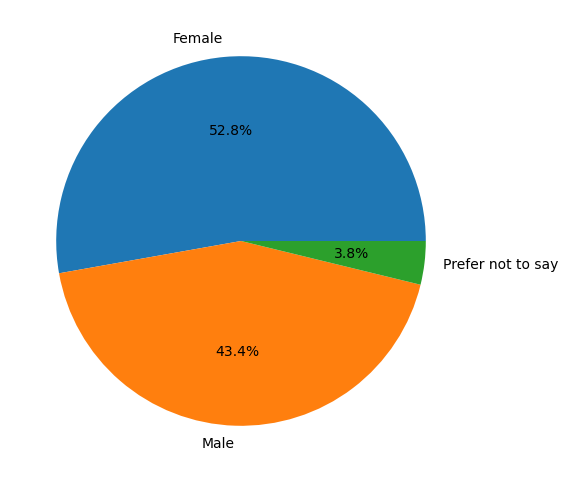

In [6]:
#Pie Chart Gender


# Group by Location and count the number of occurrences
gender_counts = df['Gender'].value_counts()

#Calculate the percentage for each location
gender_percentage = (gender_counts / len(df)) * 100

# Display the result (prints the percentages)
plt.figure(figsize = (8,6))
Location_Pie_Chart = plt.pie(gender_percentage, labels = gender_counts.index, autopct='%1.1f%%')




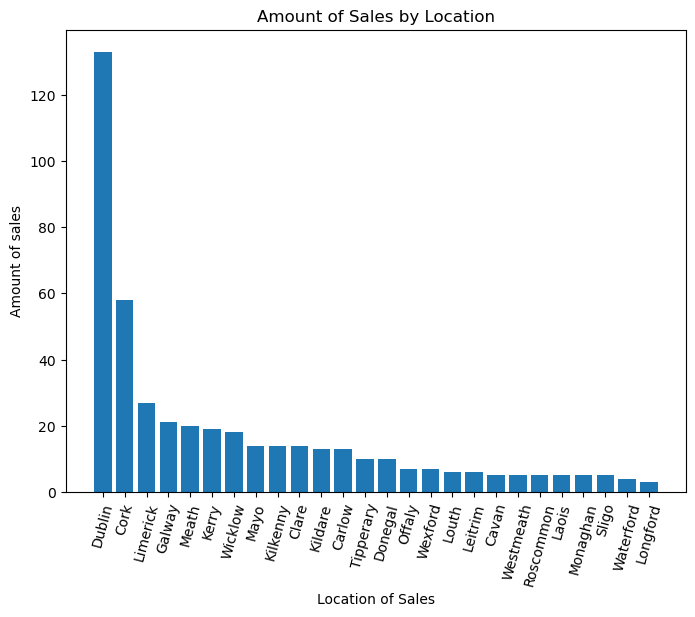

In [7]:
#bar chart sales per location
location_amount =  df['Location'].value_counts()
plt.figure(figsize=(8, 6))

#gets values and indexes
plt.bar(location_amount.index, location_amount.values)
#xAxis
plt.xlabel('Location')
#yaxis
plt.ylabel('Amount')

#title 
plt.title('Amount of Sales by Location')
plt.xlabel('Location of Sales')
plt.ylabel('Amount of sales')

#fixes location labeling on x axis
plt.xticks(rotation=75) 
#show
plt.show()

In [8]:
#sales by date
#date_counts = df['Date of Sale'].value_counts()
#print(date_counts)
#plt.figure(figsize = (8,6))

#sales_per_date = df.groupby('Date of Sale').size()

#sales_per_date.plot()
#plt.title('Sales per date')
#plt.xlabel('Date')
#plt.ylabel('Sales Amount')


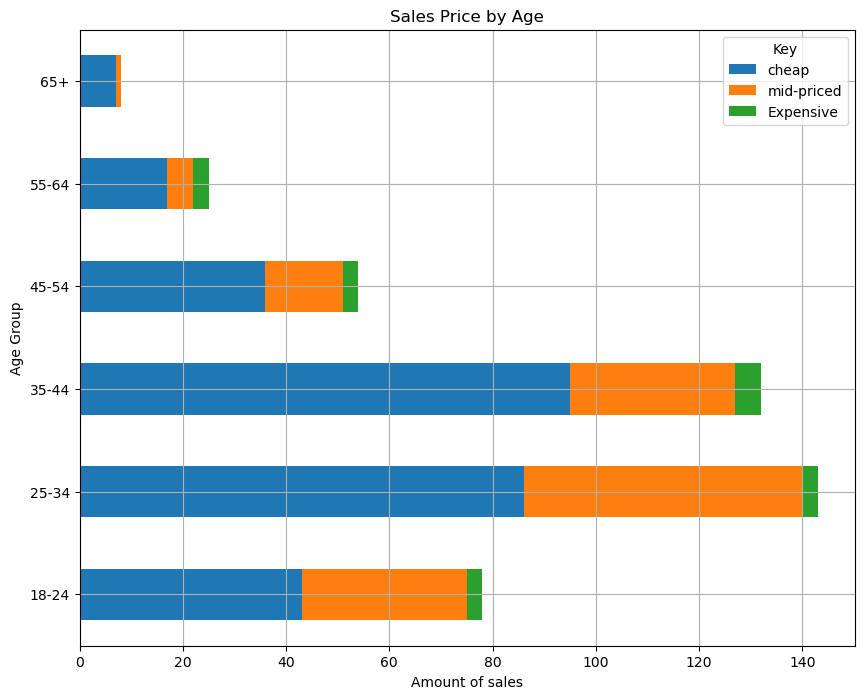

In [9]:
#Age by price

#makes it easier to graph pricing data
bins = [0, 50, 150, 500]
labels = ['cheap', 'mid-priced', 'Expensive']


#create new df column with group price
df['Key'] = pd.cut(df['Total Price'], bins=bins, labels=labels)

#using bins--> key, we create 3 diff categories of price--> easier to graph
Age_X_Product = pd.crosstab(df['Age Category'], df['Key'])
#bar chart
Age_X_Product.plot(kind='barh', stacked=True, figsize=(10, 8))
#labels
plt.title('Sales Price by Age')
plt.ylabel('Age Group')
plt.xlabel('Amount of sales')

#add grid
plt.grid(True)

Date of Sale
2023-01    483.21
2023-02    384.83
2023-03    179.16
2023-04    415.35
2023-05    247.98
2023-06    377.56
2023-07    546.50
2023-08    346.90
2023-09    297.91
2023-10    217.44
2023-11    405.17
2023-12    205.96
Freq: M, Name: Total Profit, dtype: float64


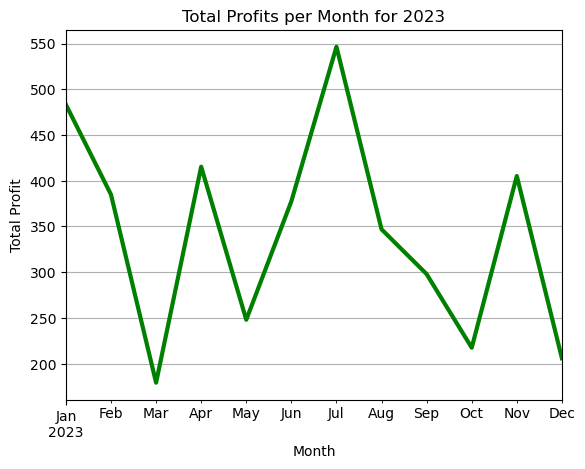

In [10]:
#since we have datetime in correct form we can easily sum of profit from each month --> this sums up profits per month and puts it in new dataset
profits_per_month = df.groupby(df['Date of Sale'].dt.to_period('M'))['Total Profit'].sum()
print(profits_per_month)
#create plot
profits_per_month.plot(kind='line', color='green', linewidth=3)

#titles and labels
plt.title("Total Profits per Month for 2023") 
plt.xlabel("Month")                            
plt.ylabel("Total Profit")                     

# Add grid
plt.grid(True)

#show 
plt.show()

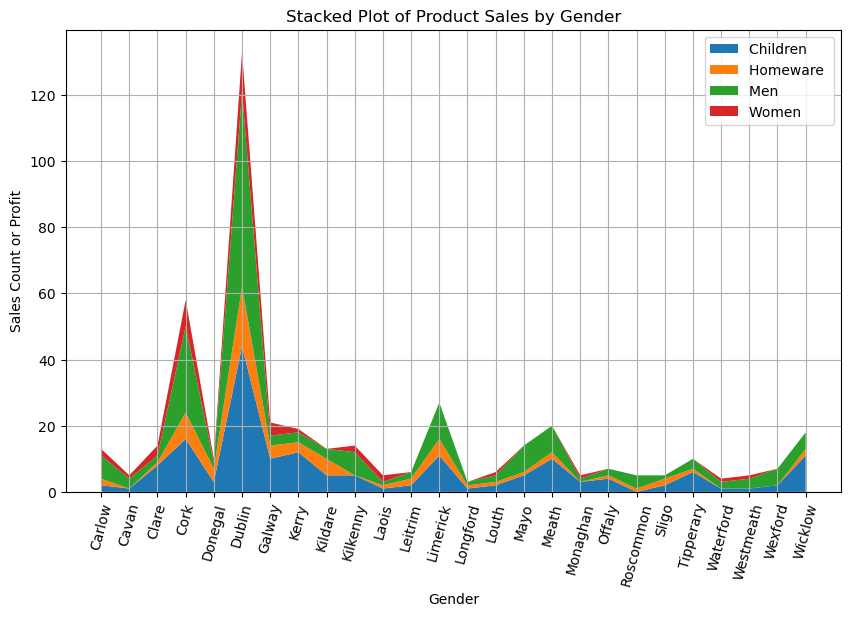

In [23]:
#relationship between gender and product type

plt.figure(figsize=(10, 6))
Gender_X_Product = pd.crosstab(df['Location'], df['Product Type'])

# Stackplot stuff
x = Gender_X_Product.index
y = [Gender_X_Product[col] for col in Gender_X_Product.columns]

#plot stacked areas
plt.stackplot(x, *y, labels=Gender_X_Product.columns)

#Labels
plt.title("Stacked Plot of Product Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Sales Count or Profit")

#grid
plt.grid(True)
plt.xticks(rotation=75) 
#color key
plt.legend(loc="upper right") 

#show
plt.show()

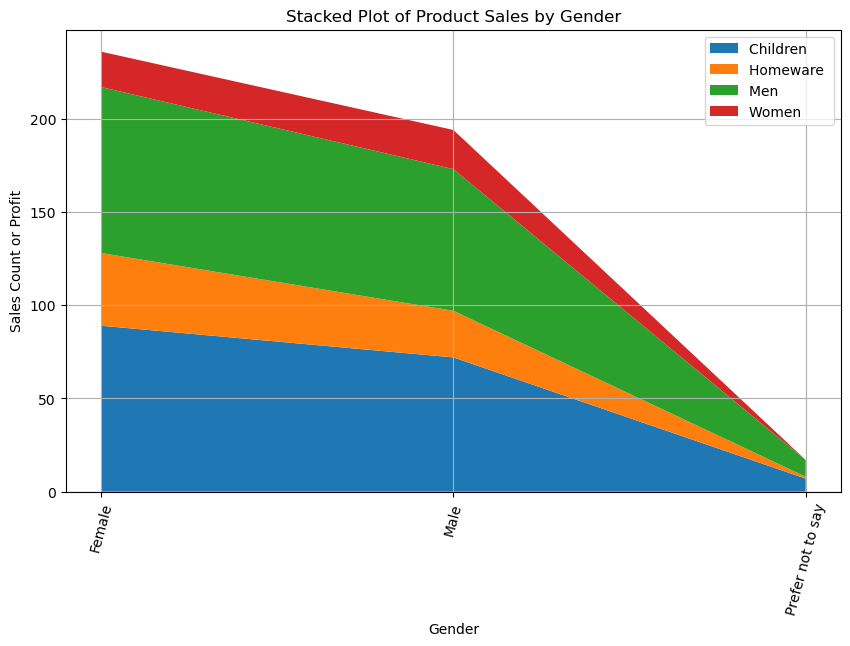

In [25]:
#relationship between gender and product type

plt.figure(figsize=(10, 6))
Gender_X_Product = pd.crosstab(df['Gender'], df['Product Type'])

# Stackplot stuff
x = Gender_X_Product.index
y = [Gender_X_Product[col] for col in Gender_X_Product.columns]

#plot stacked areas
plt.stackplot(x, *y, labels=Gender_X_Product.columns)

#Labels
plt.title("Stacked Plot of Product Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Sales Count or Profit")

#grid
plt.grid(True)
plt.xticks(rotation=75) 
#color key
plt.legend(loc="upper right") 

#show
plt.show()

In this project, the hardest part was definitely scraping the data. The data was pretty simple except the customer details. To scrape that I had use another for loop as the customer details had seperate section with different HTML syntax. Besides that, scraping the data was pretty easy. Its just one section used a whole different syntax. Fixing the date to time was a little complicated too as there are multiple different types of dates in the Date of Sale column. So I put it all in 1 type and then fixed it to the pd.datetotime so that it would be really easy to turn into months for the month profit chart.
From Graph 1, we see that females tend to order most of the stuff. 
From Graph 2, we see that most of the orders are from Dublin
From Graph 3, we see that most of the sales are coming for 35-44 range and the 25-34 range and the 18-24 range. Most sales are cheaper.
From Graph 4, we see that the most of the profits are July and Novemeber and the lowest profits are in febuary. 
From Graph 5, we can see that a lot of mens clothes are bought in dublin.
From graph 6, we see that females tend to buy most of the stuff, moreseo than men. Probablity because there are more females.

In the future, I would try to find what they make the most profit on and I would try to determine who they make the most profit on. I would use this data to follow company goals and maximize profit. Furthmore, I would convert the ID into determining if the customers are new or old customers to see if most of these are loyal old customers or newer people are buying products. Of course, only the company knows the ID database so this would only work for companies. Then I would cross reference that with the age group and see what type of age group is the new customers and determine what age group of customers we are on boarding. I think this would be extremly helpful.


